# RQ4 Feedback Prompt Analysis

Compare the six retry feedback configurations in `/root/skill/results/rq4`.

This notebook keeps `context_policy=append` fixed and studies two prompt-design axes:

- `feedback_policy`: `vague`, `error-localized`, `actionable-path`
- `feedback_format`: `full-refresh`, `stable-prefix`

The notebook focuses on three questions:

1. Which configuration gives the best score?
2. Which configuration is most token-efficient?
3. How do policy and format interact at retry time?

  在 append context 固定的前提下，RQ4 表明最好的 retry feedback 策略是“把错误点精确指
  出，并用一次聚焦的 full-refresh 重发”，而不是给模糊反馈，也不是追求稳定前缀式的提示
  如果你需要，我可以继续把这些结论整理成适合写进论文/报告的中文段落。


In [5]:
from pathlib import Path
import json
import math

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


In [6]:
RESULT_DIR = Path('/root/skill/results/rq4')
RESULT_FILES = sorted(RESULT_DIR.glob('*.json'))


def load_result(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


def safe_div(num, den):
    return num / den if den else math.nan


rows = []
attempt_rows = []

for path in RESULT_FILES:
    data = load_result(path)
    task = data['tasks'][0]
    retry = task['retry_policies']
    usage = task['usage']
    score = float(task['grading_summary']['mean'])
    label = f"{retry['feedback_policy']} | {retry['feedback_format']}"
    
    rows.append({
        'run_id': data['run_id'],
        'file': path.name,
        'label': label,
        'feedback_policy': retry['feedback_policy'],
        'feedback_format': retry['feedback_format'],
        'score': score,
        'passed': bool(task['completion']['passed']),
        'attempt_count': int(task['attempt_count']),
        'llm_rounds': int(task['llm_rounds']),
        'execution_time_s': float(task['execution_time']),
        'input_tokens': int(usage['input_tokens']),
        'output_tokens': int(usage['output_tokens']),
        'cache_read_tokens': int(usage['cache_read_tokens']),
        'cache_write_tokens': int(usage['cache_write_tokens']),
        'total_tokens': int(usage['total_tokens']),
        'score_per_1k_total_tokens': safe_div(score, int(usage['total_tokens']) / 1000),
        'score_per_1k_input_tokens': safe_div(score, int(usage['input_tokens']) / 1000),
        'tokens_per_score_total': safe_div(int(usage['total_tokens']), score),
        'tokens_per_score_input': safe_div(int(usage['input_tokens']), score),
        'cache_read_share_of_total': safe_div(int(usage['cache_read_tokens']), int(usage['total_tokens'])),
    })

    for attempt in task['attempts']:
        a_usage = attempt['execution']['usage']
        attempt_rows.append({
            'run_id': data['run_id'],
            'label': label,
            'feedback_policy': retry['feedback_policy'],
            'feedback_format': retry['feedback_format'],
            'attempt': int(attempt['attempt']),
            'score': float(attempt['grading']['score']),
            'score_delta': attempt['score_delta'],
            'transcript_length': int(attempt['transcript_length']),
            'unresolved_criteria_count': int(attempt['unresolved_criteria_count']),
            'input_tokens': int(a_usage['input_tokens']),
            'output_tokens': int(a_usage['output_tokens']),
            'cache_read_tokens': int(a_usage['cache_read_tokens']),
            'total_tokens': int(a_usage['total_tokens']),
        })

summary_df = pd.DataFrame(rows).sort_values(['score', 'score_per_1k_total_tokens'], ascending=[False, False]).reset_index(drop=True)
attempt_df = pd.DataFrame(attempt_rows).sort_values(['feedback_policy', 'feedback_format', 'attempt']).reset_index(drop=True)

summary_df[['run_id', 'feedback_policy', 'feedback_format', 'score', 'llm_rounds', 'input_tokens', 'total_tokens', 'score_per_1k_total_tokens', 'score_per_1k_input_tokens']]


,run_id,feedback_policy,feedback_format,score,llm_rounds,input_tokens,total_tokens,score_per_1k_total_tokens,score_per_1k_input_tokens
0,0019,error-localized,full-refresh,0.9167,7,7083,83468,0.0110,0.1294
1,0030,actionable-path,full-refresh,0.9017,7,5916,82095,0.0110,0.1524
2,0022,actionable-path,stable-prefix,0.8967,10,15613,123994,0.0072,0.0574
3,0018,vague,stable-prefix,0.8954,11,20189,138958,0.0064,0.0444
4,0020,error-localized,stable-prefix,0.8767,11,18380,137088,0.0064,0.0477
5,0017,vague,full-refresh,0.8667,11,16729,134607,0.0064,0.0518


## Score Comparison

First compare the six exact configurations, then look at the marginal effect of each axis.


In [7]:
score_cols = ['feedback_policy', 'feedback_format', 'score', 'passed', 'attempt_count', 'llm_rounds', 'execution_time_s']
summary_df[score_cols].sort_values('score', ascending=False)


,feedback_policy,feedback_format,score,passed,attempt_count,llm_rounds,execution_time_s
0,error-localized,full-refresh,0.9167,False,2,7,33.5881
1,actionable-path,full-refresh,0.9017,False,2,7,50.4163
2,actionable-path,stable-prefix,0.8967,False,2,10,72.7860
3,vague,stable-prefix,0.8954,False,2,11,77.1071
4,error-localized,stable-prefix,0.8767,False,2,11,46.6183
5,vague,full-refresh,0.8667,False,2,11,55.0127


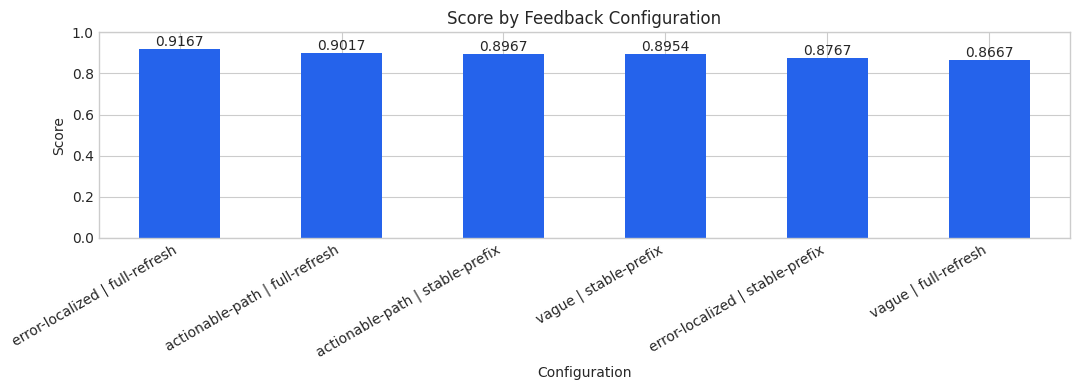

In [8]:
ax = summary_df.sort_values('score', ascending=False).plot(
    x='label', y='score', kind='bar', legend=False, figsize=(11, 4), color='#2563eb'
)
ax.set_title('Score by Feedback Configuration')
ax.set_xlabel('Configuration')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
plt.xticks(rotation=30, ha='right')
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()


In [9]:
score_policy = summary_df.groupby('feedback_policy', as_index=False).agg(
    mean_score=('score', 'mean'),
    mean_input_tokens=('input_tokens', 'mean'),
    mean_total_tokens=('total_tokens', 'mean'),
    mean_llm_rounds=('llm_rounds', 'mean'),
)
score_format = summary_df.groupby('feedback_format', as_index=False).agg(
    mean_score=('score', 'mean'),
    mean_input_tokens=('input_tokens', 'mean'),
    mean_total_tokens=('total_tokens', 'mean'),
    mean_llm_rounds=('llm_rounds', 'mean'),
)

score_policy.sort_values('mean_score', ascending=False), score_format.sort_values('mean_score', ascending=False)


(   feedback_policy  mean_score  mean_input_tokens  mean_total_tokens  \
 0  actionable-path      0.8992        10,764.5000       103,044.5000   
 1  error-localized      0.8967        12,731.5000       110,278.0000   
 2            vague      0.8810        18,459.0000       136,782.5000   
 
    mean_llm_rounds  
 0           8.5000  
 1           9.0000  
 2          11.0000  ,
   feedback_format  mean_score  mean_input_tokens  mean_total_tokens  \
 0    full-refresh      0.8950         9,909.3333       100,056.6667   
 1   stable-prefix      0.8896        18,060.6667       133,346.6667   
 
    mean_llm_rounds  
 0           8.3333  
 1          10.6667  )

In [10]:
score_pivot = summary_df.pivot(index='feedback_policy', columns='feedback_format', values='score')
score_pivot


feedback_format,full-refresh,stable-prefix
feedback_policy,,
actionable-path,0.9017,0.8967
error-localized,0.9167,0.8767
vague,0.8667,0.8954


## Token Efficiency Comparison

As in RQ2, use both overall-token and prompt-input views:

- `score_per_1k_total_tokens`: score divided by all tokens in the logged run
- `score_per_1k_input_tokens`: score divided by non-cache input tokens only


In [11]:
eff_cols = [
    'feedback_policy',
    'feedback_format',
    'score',
    'input_tokens',
    'cache_read_tokens',
    'total_tokens',
    'score_per_1k_total_tokens',
    'score_per_1k_input_tokens',
    'tokens_per_score_total',
    'tokens_per_score_input',
]
summary_df[eff_cols].sort_values('score_per_1k_total_tokens', ascending=False)


,feedback_policy,feedback_format,score,input_tokens,cache_read_tokens,total_tokens,score_per_1k_total_tokens,score_per_1k_input_tokens,tokens_per_score_total,tokens_per_score_input
1,actionable-path,full-refresh,0.9017,5916,62478,82095,0.0110,0.1524,"91,048.0591","6,561.1830"
0,error-localized,full-refresh,0.9167,7083,72951,83468,0.0110,0.1294,"91,056.0000","7,726.9091"
2,actionable-path,stable-prefix,0.8967,15613,104190,123994,0.0072,0.0574,"138,283.2714","17,412.2677"
3,vague,stable-prefix,0.8954,20189,114603,138958,0.0064,0.0444,"155,188.0875","22,547.0451"
5,vague,full-refresh,0.8667,16729,104130,134607,0.0064,0.0518,"155,315.7692","19,302.6923"
4,error-localized,stable-prefix,0.8767,18380,114603,137088,0.0064,0.0477,"156,374.1445","20,965.7795"


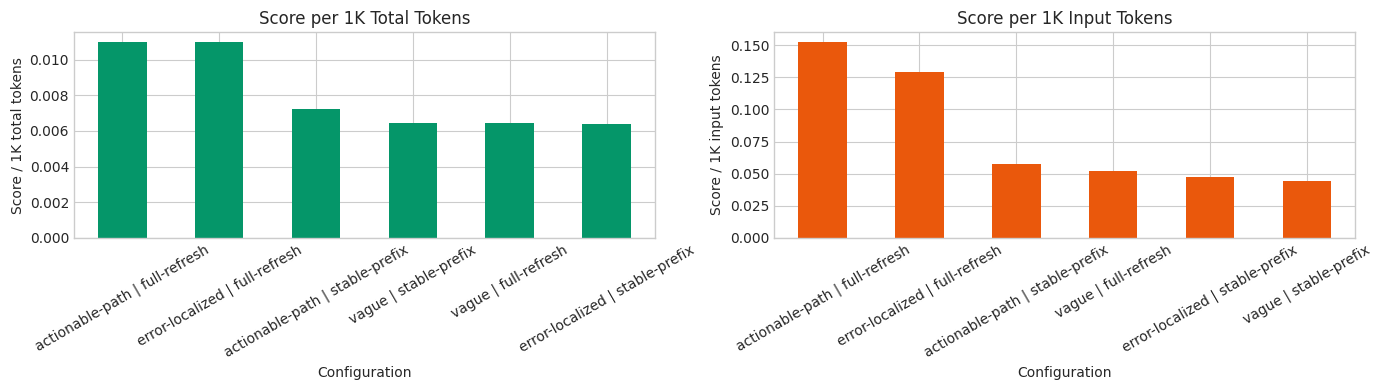

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

summary_df.sort_values('score_per_1k_total_tokens', ascending=False).plot(
    x='label', y='score_per_1k_total_tokens', kind='bar', legend=False, ax=axes[0], color='#059669'
)
axes[0].set_title('Score per 1K Total Tokens')
axes[0].set_xlabel('Configuration')
axes[0].set_ylabel('Score / 1K total tokens')
axes[0].tick_params(axis='x', rotation=30)

summary_df.sort_values('score_per_1k_input_tokens', ascending=False).plot(
    x='label', y='score_per_1k_input_tokens', kind='bar', legend=False, ax=axes[1], color='#ea580c'
)
axes[1].set_title('Score per 1K Input Tokens')
axes[1].set_xlabel('Configuration')
axes[1].set_ylabel('Score / 1K input tokens')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


In [13]:
token_pivot = summary_df.pivot_table(
    index='feedback_policy',
    columns='feedback_format',
    values=['input_tokens', 'total_tokens', 'score_per_1k_total_tokens', 'score_per_1k_input_tokens']
)
token_pivot


input_tokens               score_per_1k_input_tokens  \
feedback_format full-refresh stable-prefix              full-refresh   
feedback_policy                                                        
actionable-path   5,916.0000   15,613.0000                    0.1524   
error-localized   7,083.0000   18,380.0000                    0.1294   
vague            16,729.0000   20,189.0000                    0.0518   

                              score_per_1k_total_tokens                \
feedback_format stable-prefix              full-refresh stable-prefix   
feedback_policy                                                         
actionable-path        0.0574                    0.0110        0.0072   
error-localized        0.0477                    0.0110        0.0064   
vague                  0.0444                    0.0064        0.0064   

                total_tokens                
feedback_format full-refresh stable-prefix  
feedback_policy                             
actionable-path  82,095.0000  123,994.0000  
error-localized  83,468.0000  137,088.0000  
vague           134,607.0000  138,958.0000

## Attempt-Level Dynamics

RQ4 is really about retry prompt design, so attempt-level behavior matters more than aggregate totals.


In [14]:
attempt_df[['feedback_policy', 'feedback_format', 'attempt', 'score', 'score_delta', 'unresolved_criteria_count', 'input_tokens', 'total_tokens', 'transcript_length']]


,feedback_policy,feedback_format,attempt,score,score_delta,unresolved_criteria_count,input_tokens,total_tokens,transcript_length
0,actionable-path,full-refresh,1,0.8817,NaN,3,1835,44306,12
1,actionable-path,full-refresh,2,0.9017,0.0200,2,4081,37789,18
2,actionable-path,stable-prefix,1,0.8667,NaN,4,1626,44024,12
3,actionable-path,stable-prefix,2,0.8967,0.0300,4,13987,79970,24
4,error-localized,full-refresh,1,0.9167,NaN,1,2076,44761,12
5,error-localized,full-refresh,2,0.9167,0.0000,1,5007,38707,18
6,error-localized,stable-prefix,1,0.8617,NaN,4,2021,44692,12
7,error-localized,stable-prefix,2,0.8767,0.0150,5,16359,92396,26
8,vague,full-refresh,1,0.8617,NaN,4,2844,55980,14
9,vague,full-refresh,2,0.8667,0.0050,4,13885,78627,27


In [15]:
attempt_token_pivot = attempt_df.pivot(index='label', columns='attempt', values='input_tokens').rename(columns=lambda c: f'attempt_{c}_input')
attempt_token_pivot


attempt,attempt_1_input,attempt_2_input
label,,
actionable-path | full-refresh,1835,4081
actionable-path | stable-prefix,1626,13987
error-localized | full-refresh,2076,5007
error-localized | stable-prefix,2021,16359
vague | full-refresh,2844,13885
vague | stable-prefix,1701,18488


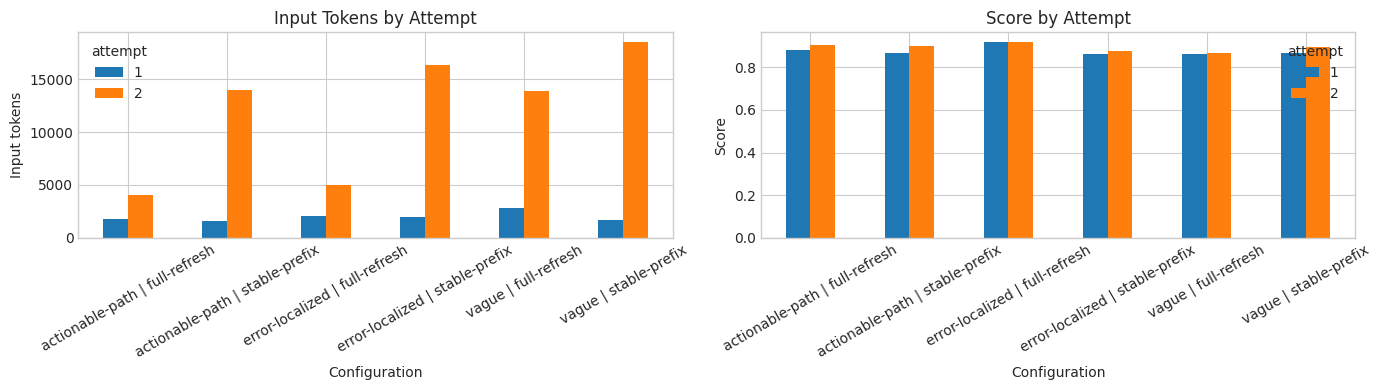

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

attempt_df.pivot(index='label', columns='attempt', values='input_tokens').plot(kind='bar', ax=axes[0])
axes[0].set_title('Input Tokens by Attempt')
axes[0].set_xlabel('Configuration')
axes[0].set_ylabel('Input tokens')
axes[0].tick_params(axis='x', rotation=30)

attempt_df.pivot(index='label', columns='attempt', values='score').plot(kind='bar', ax=axes[1])
axes[1].set_title('Score by Attempt')
axes[1].set_xlabel('Configuration')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


In [17]:
improvement_df = attempt_df[attempt_df['attempt'] == 2][[
    'feedback_policy',
    'feedback_format',
    'score_delta',
    'unresolved_criteria_count',
    'input_tokens',
    'total_tokens',
]].sort_values(['score_delta', 'input_tokens'], ascending=[False, True])
improvement_df


,feedback_policy,feedback_format,score_delta,unresolved_criteria_count,input_tokens,total_tokens
3,actionable-path,stable-prefix,0.0300,4,13987,79970
11,vague,stable-prefix,0.0288,4,18488,94763
1,actionable-path,full-refresh,0.0200,2,4081,37789
7,error-localized,stable-prefix,0.0150,5,16359,92396
9,vague,full-refresh,0.0050,4,13885,78627
5,error-localized,full-refresh,0.0000,1,5007,38707


## Ranking and Interpretation


In [18]:
score_ranking = summary_df[['feedback_policy', 'feedback_format', 'score', 'llm_rounds', 'total_tokens']].sort_values(
    ['score', 'total_tokens'], ascending=[False, True]
).reset_index(drop=True)
score_ranking.index = score_ranking.index + 1
score_ranking


,feedback_policy,feedback_format,score,llm_rounds,total_tokens
1,error-localized,full-refresh,0.9167,7,83468
2,actionable-path,full-refresh,0.9017,7,82095
3,actionable-path,stable-prefix,0.8967,10,123994
4,vague,stable-prefix,0.8954,11,138958
5,error-localized,stable-prefix,0.8767,11,137088
6,vague,full-refresh,0.8667,11,134607


In [19]:
eff_ranking = summary_df[['feedback_policy', 'feedback_format', 'score_per_1k_total_tokens', 'score_per_1k_input_tokens', 'tokens_per_score_total', 'tokens_per_score_input']].sort_values(
    'score_per_1k_total_tokens', ascending=False
).reset_index(drop=True)
eff_ranking.index = eff_ranking.index + 1
eff_ranking


,feedback_policy,feedback_format,score_per_1k_total_tokens,score_per_1k_input_tokens,tokens_per_score_total,tokens_per_score_input
1,actionable-path,full-refresh,0.0110,0.1524,"91,048.0591","6,561.1830"
2,error-localized,full-refresh,0.0110,0.1294,"91,056.0000","7,726.9091"
3,actionable-path,stable-prefix,0.0072,0.0574,"138,283.2714","17,412.2677"
4,vague,stable-prefix,0.0064,0.0444,"155,188.0875","22,547.0451"
5,vague,full-refresh,0.0064,0.0518,"155,315.7692","19,302.6923"
6,error-localized,stable-prefix,0.0064,0.0477,"156,374.1445","20,965.7795"


In [20]:
best_score = summary_df.sort_values(['score', 'total_tokens'], ascending=[False, True]).iloc[0]
best_eff_total = summary_df.sort_values('score_per_1k_total_tokens', ascending=False).iloc[0]
best_eff_input = summary_df.sort_values('score_per_1k_input_tokens', ascending=False).iloc[0]
largest_gain = attempt_df[attempt_df['attempt'] == 2].sort_values(['score_delta', 'input_tokens'], ascending=[False, True]).iloc[0]

print('Best score configuration:', f"{best_score['feedback_policy']} + {best_score['feedback_format']}", f"(score={best_score['score']:.4f}, total_tokens={int(best_score['total_tokens'])})")
print('Best total-token efficiency:', f"{best_eff_total['feedback_policy']} + {best_eff_total['feedback_format']}", f"(score_per_1k_total_tokens={best_eff_total['score_per_1k_total_tokens']:.4f})")
print('Best input-token efficiency:', f"{best_eff_input['feedback_policy']} + {best_eff_input['feedback_format']}", f"(score_per_1k_input_tokens={best_eff_input['score_per_1k_input_tokens']:.4f})")
print('Largest attempt-2 gain:', f"{largest_gain['feedback_policy']} + {largest_gain['feedback_format']}", f"(score_delta={largest_gain['score_delta']:.4f}, attempt_2_input={int(largest_gain['input_tokens'])})")

print('\nPolicy means:')
for _, row in score_policy.sort_values('mean_score', ascending=False).iterrows():
    print(
        f"- {row['feedback_policy']}: mean_score={row['mean_score']:.4f}, "
        f"mean_input={row['mean_input_tokens']:.1f}, mean_total={row['mean_total_tokens']:.1f}, "
        f"mean_rounds={row['mean_llm_rounds']:.1f}"
    )

print('\nFormat means:')
for _, row in score_format.sort_values('mean_score', ascending=False).iterrows():
    print(
        f"- {row['feedback_format']}: mean_score={row['mean_score']:.4f}, "
        f"mean_input={row['mean_input_tokens']:.1f}, mean_total={row['mean_total_tokens']:.1f}, "
        f"mean_rounds={row['mean_llm_rounds']:.1f}"
    )

print('\nConfiguration summary:')
for _, row in summary_df.sort_values(['feedback_policy', 'feedback_format']).iterrows():
    print(
        f"- {row['feedback_policy']} + {row['feedback_format']}: score={row['score']:.4f}, "
        f"rounds={int(row['llm_rounds'])}, input={int(row['input_tokens'])}, total={int(row['total_tokens'])}, "
        f"score/1k_total={row['score_per_1k_total_tokens']:.4f}, score/1k_input={row['score_per_1k_input_tokens']:.4f}"
    )


Best score configuration: error-localized + full-refresh (score=0.9167, total_tokens=83468)
Best total-token efficiency: actionable-path + full-refresh (score_per_1k_total_tokens=0.0110)
Best input-token efficiency: actionable-path + full-refresh (score_per_1k_input_tokens=0.1524)
Largest attempt-2 gain: actionable-path + stable-prefix (score_delta=0.0300, attempt_2_input=13987)

Policy means:
- actionable-path: mean_score=0.8992, mean_input=10764.5, mean_total=103044.5, mean_rounds=8.5
- error-localized: mean_score=0.8967, mean_input=12731.5, mean_total=110278.0, mean_rounds=9.0
- vague: mean_score=0.8810, mean_input=18459.0, mean_total=136782.5, mean_rounds=11.0

Format means:
- full-refresh: mean_score=0.8950, mean_input=9909.3, mean_total=100056.7, mean_rounds=8.3
- stable-prefix: mean_score=0.8896, mean_input=18060.7, mean_total=133346.7, mean_rounds=10.7

Configuration summary:
- actionable-path + full-refresh: score=0.9017, rounds=7, input=5916, total=82095, score/1k_total=0.011